In [1]:
import json
import os
import re
import csv
import io
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from thefuzz import fuzz
from tqdm.notebook import tqdm

In [2]:
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

In [3]:
given_data = pd.read_csv("~/Box/dsi-core/11th-hour/good-food-purchasing/nov2025-dataset/cleaned-by-vy.csv")

In [4]:
given_data.columns

Index(['Product Type', 'Food Product Group', 'Food Product Category',
       'Primary Food Product Category', 'Product Name', 'Basic Type',
       'Sub-Type 1', 'Sub-Type 2', 'Sub-Type 3', 'Flavor/Cut', 'Shape', 'Skin',
       'Seed/Bone', 'Processing', 'Cooked/Cleaned', 'WG/WGR',
       'Dietary Concern', 'Additives', 'Dietary Accommodation', 'Frozen',
       'Packaging', 'Commodity', 'Multiple Names'],
      dtype='object')

In [5]:
SORT_ORDER = [
    "Basic Type", "Sub-Type 1", "Sub-Type 2", "Sub-Type 3", "Flavor/Cut", "Shape",
    "Skin", "Seed/Bone", "Processing", "Cooked/Cleaned", "WG/WGR", "Dietary Concern",
    "Additives", "Dietary Accommodation", "Frozen", "Packaging", "Commodity",
    "Food Product Group", "Food Product Category", "Primary Food Product Category",
]

BATCH_SIZE = 20

with open("category-instructions.md") as file:
    category_instructions = file.read()

NUM_SAMPLES = 5
TIMEOUT = 60  # seconds
SPACES = re.compile(r"\s+")

In [6]:
def make_original(batchdf):
    original = []
    for counter, (_, row) in enumerate(batchdf.iterrows()):
        name = SPACES.sub(" ", row["Product Type"].strip().upper())
        category = row["Food Product Category"].strip()
        subcategory = row["Primary Food Product Category"].strip()
        if category == subcategory:
            subcategory = ""
        original.append([str(counter + 1), name, category, subcategory])
    return original

In [7]:
def chatgpt_responses(original, is_correcting):
    with io.StringIO() as output:
        writer = csv.writer(output)
        writer.writerow(["index", "name", "category", "subcategory"])
        for line in original:
            writer.writerow(line if is_correcting else line[:2])
        user_message = output.getvalue()

    if is_correcting:
        system_message = f"""
Your job is to read a set of food product names, determine whether categories have been correctly applied,
and correct them if they are incorrect. The data consist of a numerical `index`, the `name` (input),
the `category` (output) and sometimes a `subcategory` (output), as CSV. If the `category` and `subcategory`
have been correctly applied, copy the input data *exactly* in your output. Otherwise, copy the `index` and `name`
*exactly*, but replace the `category` and `subcategory` with the correct value. If there is no `subcategory`,
represent it with an empty string. Every row of data is equally important!

{category_instructions}
""".strip()
    else:
        system_message = f"""
Your job is to read a set of food product names and categorize them. The data consist of a numerical `index`
and `name` as CSV. In your output, copy the `index` and `name` *exactly* and add two columns: `category` and
`subcategory`, which can be an empty string if it is missing. Every row of data is equally important!

{category_instructions}
""".strip()

    response = requests.post(
        "https://api.openai.com/v1/chat/completions",
        timeout=TIMEOUT,
        headers={
            "Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}",
            "Content-Type": "application/json",
        },
        json={
            "model": "gpt-4.1-mini",
            "messages": [
                {"role": "system", "content": system_message},
                {"role": "user", "content": f"""
```csv
{user_message}
```
""".strip()},
            ],
            "n": NUM_SAMPLES,
        },
    )

    distribution_category = [Counter() for _ in range(len(original))]
    distribution_subcategory = [Counter() for _ in range(len(original))]
    distribution_both = [0 for _ in range(len(original))]

    for choice in response.json()["choices"]:
        lines = [x for x in csv.reader(io.StringIO(choice["message"]["content"])) if x[0].strip() not in ("```csv", "```")]
        if [x.strip() for x in lines[0]] == ["index", "name", "category", "subcategory"]:
            lines = lines[1:]
        assert len(lines) == len(original), f"{len(lines)} lines != {len(original)} lines"
        assert [int(line[0]) for line in lines] == list(range(1, len(lines) + 1)), f"indexes are {[int(line[0]) for line in lines]}"
        for index, (new_line, original_line) in enumerate(zip(lines, original)):
            assert fuzz.ratio(new_line[1].strip(), original_line[1]) > 90, f"item {new_line[1].strip()!r} != {original_line[1]!r}"
            new_line += [""] * max(0, 4 - len(new_line))
            new_category = new_line[2].strip()
            new_subcategory = new_line[3].strip()
            category_correct = new_category == original_line[2]
            subcategory_correct = new_subcategory == original_line[3]

            if category_correct:
                distribution_category[index]["\u2713"] += 1
            else:
                distribution_category[index][new_category] += 1

            if subcategory_correct:
                distribution_subcategory[index]["\u2713"] += 1
            else:
                distribution_subcategory[index][new_subcategory] += 1

            if category_correct and subcategory_correct:
                distribution_both[index] += 1

    return distribution_category, distribution_subcategory, distribution_both

In [8]:
def format_distribution(distribution):
    return f"{distribution.get('\u2713', 0)}\u2713" + (", " if len(distribution | {"\u2713": None}) > 1 else "") + ", ".join(
        f"{count} {value}" for value, count in distribution.items() if value != "\u2713"
    )

def print_distribution_category(original, distribution_category):
    for (name, category), categories in zip([x[1:3] for x in original], distribution_category):
        print(f"{name:70s} | {category:30s} | {format_distribution(categories)}")

def print_distribution_subcategory(original, distribution_subcategory):
    for (name, _, subcategory), subcategories in zip([x[1:4] for x in original], distribution_subcategory):
        print(f"{name:70s} | {subcategory:30s} | {format_distribution(subcategories)}")

In [9]:
hist_correct2 = np.zeros((NUM_SAMPLES + 1, NUM_SAMPLES + 1), dtype=int)

batchdfs = []
for _, df in given_data.sort_values(SORT_ORDER).groupby("Basic Type"):
    for start_index in range(0, len(df), BATCH_SIZE):
        batchdf = df.iloc[start_index : start_index + BATCH_SIZE]
        if len(batchdf) == BATCH_SIZE:
            batchdfs.append(batchdf)

batchdfs = [batchdfs[i] for i in np.random.permutation(np.arange(len(batchdfs)))]

for batchdf in tqdm(batchdfs[:10]):
    original = make_original(batchdf)
    try:
        _, _, distribution_correcting = chatgpt_responses(original, True)
        _, _, distribution_reckoning = chatgpt_responses(original, False)
    except Exception as err:
        print(f"{type(err).__name__}: {str(err)}")
        continue

    for correcting, reckoning in zip(distribution_correcting, distribution_reckoning):
        hist_correct2[correcting, reckoning] += 1

  0%|          | 0/10 [00:00<?, ?it/s]

AssertionError: item 'FRANCZOZ WHOLE WHITE WHEAT DINNER ROLL' != 'FRANCZOZ WHOLE WHITE WHEAT DINNER ROLL, 12CT. BAGS X 10/CASE'
AssertionError: item 'JUICE, APPL 100% CNCNT ASPTC FRUIT' != 'JUICE, APPL 100% CNCNT ASPTC'
AssertionError: item 'TEA' != 'TEA, ICED BREW BAG FP'


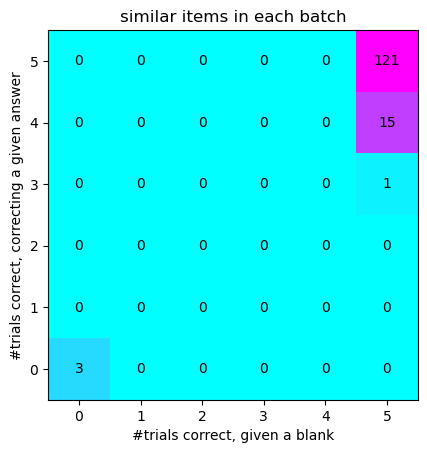

In [10]:
fig, ax = plt.subplots()

ax.imshow(hist_correct2, cmap="cool", interpolation="none", vmin=0, vmax=20, origin="lower")

for (i, j), count in np.ndenumerate(hist_correct2):
    ax.text(j, i, str(count), ha="center", va="center", color="black")

ax.set_title("similar items in each batch")
ax.set_xlabel("#trials correct, given a blank")
ax.set_ylabel("#trials correct, correcting a given answer")

None

In [11]:
hist_correct = np.zeros((NUM_SAMPLES + 1, NUM_SAMPLES + 1), dtype=int)

randomizeddf = given_data.iloc[np.random.permutation(np.arange(len(given_data)))]

for start_index in tqdm(range(0, 10*BATCH_SIZE, BATCH_SIZE)):
    batchdf = randomizeddf.iloc[start_index : start_index + BATCH_SIZE]

    original = make_original(batchdf)
    try:
        _, _, distribution_correcting = chatgpt_responses(original, True)
        _, _, distribution_reckoning = chatgpt_responses(original, False)
    except Exception as err:
        print(f"{type(err).__name__}: {str(err)}")
        continue

    for correcting, reckoning in zip(distribution_correcting, distribution_reckoning):
        hist_correct[correcting, reckoning] += 1

  0%|          | 0/10 [00:00<?, ?it/s]

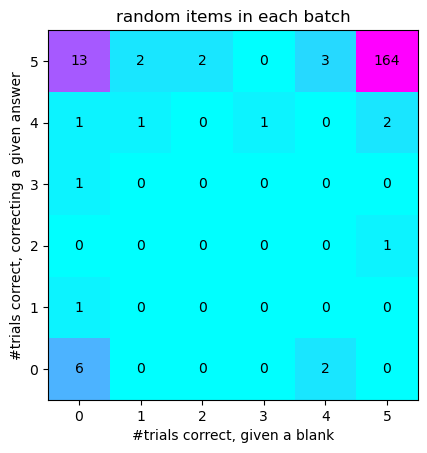

In [12]:
fig, ax = plt.subplots()

ax.imshow(hist_correct, cmap="cool", interpolation="none", vmin=0, vmax=20, origin="lower")

for (i, j), count in np.ndenumerate(hist_correct):
    ax.text(j, i, str(count), ha="center", va="center", color="black")

ax.set_title("random items in each batch")
ax.set_xlabel("#trials correct, given a blank")
ax.set_ylabel("#trials correct, correcting a given answer")

None

In [23]:
randomizeddf[["Product Type", "Food Product Category", "Primary Food Product Category", "Basic Type"]].iloc[:10]

,Product Type,Food Product Category,Primary Food Product Category,Basic Type
72649,PIZZA CRUST PRBKD RSD EDG 14IN,Grain Products,Grain Products,crust
27044,CHICKEN NUGGET CKD WHL GRAIN,Chicken,Chicken,chicken
82481,Sauce Mexican Taco Ss Mild K-12 Commodity Capa...,Condiments & Snacks,Condiments & Snacks,sauce
21100,"CARROTS, DICED",Roots & Tubers,Roots & Tubers,carrot
93134,"TABLECOVER, TISSUE 54""X108"" FOLDED RED 2 PLY P...",Non-Food,Non-Food,NaN
58585,"MEAL TURKEY W. GRAVY,STUFFING",Meals,"Turkey, Other Poultry",meal kit
59661,MILK SKIM A2 1/2 GAL ORIGIN MILK LCL,Milk,Milk,milk
24050,CHEESE CREAM NEUFCH LOAF,Cheese,Cheese,cream cheese
2721,22930 RED BELL PEPPERS 5 LB,Vegetables,Vegetables,pepper
18911,CABBAGE-GREEN-SHREDDED,Vegetables,Vegetables,cabbage


In [22]:
list(given_data.sort_values(SORT_ORDER).groupby("Basic Type"))[2][1][["Product Type", "Food Product Category", "Primary Food Product Category", "Basic Type"]].iloc[:10]

,Product Type,Food Product Category,Primary Food Product Category,Basic Type
5022,"ADDITIVE, AGAR ARTISTRE SHLF",Condiments & Snacks,Condiments & Snacks,additives
5023,"ADDITIVE, AGAR ARTISTRE SHLF (2674315)",Condiments & Snacks,Condiments & Snacks,additives
36636,CUISINE TECH AGAR AGAR 1 LB,Condiments & Snacks,Condiments & Snacks,additives
38530,DOUGH CONDITIONER IBIS SILVER,Condiments & Snacks,Condiments & Snacks,additives
80885,SALADIZER 250 PH (50#),Condiments & Snacks,Condiments & Snacks,additives
44206,FOOD ADDTV TAPIOCA MALTODEXTRI,Condiments & Snacks,Condiments & Snacks,additives
69875,"PECTIN, LIQUID FRUIT (921958)",Condiments & Snacks,Condiments & Snacks,additives
94296,"THICKENER, FOOD & BEVERAGE GEL HONEY SS PACKET...",Condiments & Snacks,Condiments & Snacks,additives
94291,"THICKENER, FOOD & BEV GEL HONY",Condiments & Snacks,Condiments & Snacks,additives
94295,"THICKENER, FOOD & BEVERAGE GEL HONEY SS PACKET...",Condiments & Snacks,Condiments & Snacks,additives


In [25]:
hist_correct.sum()

np.int64(200)